# OPERA DSWx (S2 HLS)

In this notebook we are going to download water masks (Dynamic Surface Water - DSW) from OPERA project. There are 2 good references:
* https://github.com/OPERA-Cal-Val/OPERA_Applications/blob/main/DSWx/Mosaics/notebooks/Create-mosaics.ipynb
* https://github.com/OPERA-Cal-Val/OPERA_Applications/blob/main/DSWx/Discover/Stream_and_Viz_DSWx-HLS_viaCMR-STAC.ipynb


## Earthaccess

We will first, try to download what we want by using `earthaccess`.

In [1]:
%load_ext autoreload
%autoreload 2

import earthaccess
import hvplot.xarray  # noqa: F401
import rasterio as rio
import rioxarray as xrio
import xarray as xr
from bokeh.models import FixedTicker

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.opera import (
    calc_aoi_stats,
    fill_df_with_stats,
    opera_results_to_df,
    search_opera,
)
from swot_toolkit.swot import auth_earthaccess


In [2]:
auth_earthaccess()

## Open the AOI

In [3]:
# Read geometry from a KML file
AOIs = read_kml_geometry("/data/swot/AOIs/Curua-Una.kml")
# Define the date range and Sentinel-2 tile
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"

if AOIs is not None:
    AOI = AOIs[0]

In [4]:
opera_items = search_opera(
    aoi=AOI.centroid,
    date_range=(START_DATE, END_DATE),
)

len(opera_items)

241

In [16]:
opera_df = opera_results_to_df(opera_items)
opera_df

,tile,date_str,satellite,item,datetime
date,,,,,
2024-01-04,T21MYS,20240104T140701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-04 14:07:01
2024-01-11,T21MYS,20240111T135701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-11 13:57:01
2024-01-16,T21MYS,20240116T135659Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-16 13:56:59
2024-01-19,T21MYS,20240119T140709Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-19 14:07:09
2024-01-21,T21MYS,20240121T135651Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-21 13:56:51
...,...,...,...,...,...
2025-06-26,T21MYS,20250626T140111Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2025-06-26 14:01:11
2025-06-27,T21MYS,20250627T141111Z,S2C,"{'meta': {'concept-type': 'granule', 'concept-...",2025-06-27 14:11:11
2025-06-29,T21MYS,20250629T135408Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2025-06-29 13:54:08


In [17]:
opera_df = fill_df_with_stats(
    opera_df=opera_df,
    aoi=AOI,
    use_bounds=True,
    crs="epsg:4326",
    columns=["perc_valid"],
)

Calculating stats for OPERA:   0%|          | 0/241 [00:00<?, ?it/s]

In [20]:
opera_df.sort_values(by="perc_valid", ascending=False).iloc[:10]

,tile,date_str,satellite,item,datetime,perc_valid
date,,,,,,
2024-11-10,T21MYS,20241110T134813Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2024-11-10 13:48:13,99.98
2024-09-23,T21MYS,20240923T134806Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2024-09-23 13:48:06,99.34
2024-08-08,T21MYS,20240808T140051Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-08 14:00:51,98.93
2024-07-19,T21MYS,20240719T135701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-07-19 13:57:01,97.92
2024-09-02,T21MYS,20240902T135709Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2024-09-02 13:57:09,95.84
2024-09-27,T21MYS,20240927T135701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-09-27 13:57:01,86.89
2024-07-21,T21MYS,20240721T134748Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2024-07-21 13:47:48,84.45
2024-08-06,T21MYS,20240806T134745Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-06 13:47:45,82.20
2024-11-06,T21MYS,20241106T135701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-11-06 13:57:01,78.97


In [197]:
opera_df

,tile,date_str,satellite,item,datetime,perc_valid
date,,,,,,
2024-01-04,T21MYS,20240104T140701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-04 14:07:01,0.0


In [189]:
earthaccess.open?

Signature:
earthaccess.open(
    granules: Union[List[str], List[earthaccess.results.DataGranule]],
    provider: Optional[str] = None,
    *,
    pqdm_kwargs: Optional[Mapping[str, Any]] = None,
) -> List[fsspec.spec.AbstractFileSystem]
Docstring:
Returns a list of file-like objects that can be used to access files
hosted on S3 or HTTPS by third party libraries like xarray.

Parameters:
    granules: a list of granule instances **or** list of URLs, e.g. `s3://some-granule`.
        If a list of URLs is passed, we need to specify the data provider.
    provider: e.g. POCLOUD, NSIDC_CPRD, etc.
    pqdm_kwargs: Additional keyword arguments to pass to pqdm, a parallel processing library.
        See pqdm documentation for available options. Default is to use immediate exception behavior
        and the number of jobs specified by the `threads` parameter.

Returns:
    A list of "file pointers" to remote (i.e. s3 or https) files.
File:      /usr/local/lib/python3.12/dist-packages/earthacce

In [41]:
from swot_toolkit.utils import find_closest_items

In [45]:
closest_items = find_closest_items("2025-05-26", opera_df)
closest_items

,tile,date_str,satellite,item,datetime,delta
date,,,,,,
2025-05-25,T21MYS,20250525T135721Z,S2C,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-25 13:57:21,-1 days +13:57:21
2025-05-27,T21MYS,20250527T140111Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-27 14:01:11,1 days 14:01:11
2025-05-23,T21MYS,20250523T140709Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-23 14:07:09,-3 days +14:07:09
2025-05-28,T21MYS,20250528T135352Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-28 13:53:52,2 days 13:53:52
2025-05-28,T21MYS,20250528T140811Z,S2C,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-28 14:08:11,2 days 14:08:11
2025-05-28,T21MYS,20250528T135352Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-28 13:53:52,2 days 13:53:52
2025-05-28,T21MYS,20250528T140811Z,S2C,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-28 14:08:11,2 days 14:08:11
2025-05-21,T21MYS,20250521T134739Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-21 13:47:39,-5 days +13:47:39
2025-05-30,T21MYS,20250530T135709Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2025-05-30 13:57:09,4 days 13:57:09


In [47]:
closest_items["delta"].abs()

date
2025-05-25   0 days 10:02:39
2025-05-27   1 days 14:01:11
2025-05-23   2 days 09:52:51
2025-05-28   2 days 13:53:52
2025-05-28   2 days 14:08:11
2025-05-28   2 days 13:53:52
2025-05-28   2 days 14:08:11
2025-05-21   4 days 10:12:21
2025-05-30   4 days 13:57:09
2025-05-30   4 days 14:11:01
2025-05-30   4 days 13:57:09
2025-05-30   4 days 14:11:01
Name: delta, dtype: timedelta64[ns]

In [205]:
earthaccess.open([granule], pqdm_kwargs={"disable": True})

[<File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B01_WTR.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B02_BWTR.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B03_CONF.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B04_DIAG.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21M

## Search for SWOT images

In [5]:
# Search for products within the AOI and Time frame
results: list[earthaccess.DataGranule] = earthaccess.search_data(
    short_name="OPERA_L3_DSWX-HLS_V1",
    temporal=(START_DATE, END_DATE),
    bounding_box=AOI.centroid.bounds,
)

len(results)

241

In [87]:
results[85]

Collection: {'Version': '1.0', 'ShortName': 'OPERA_L3_DSWX-HLS_V1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -55.24506996682664, 'SouthBoundingCoordinate': -3.6614789250498787, 'EastBoundingCoordinate': -54.25542990548235, 'NorthBoundingCoordinate': -2.6667700734968305}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2024-08-08T14:03:28.978Z', 'BeginningDateTime': '2024-08-08T14:03:28.978Z'}}
Size(MB): 40.40441703796387
Data: ['https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B01_WTR.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B02_BWTR.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B03_CONF.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B04_DIAG.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B05_WTR-1.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B06_WTR-2.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B07_LAND.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B08_SHAD.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B09_CLOUD.tif', 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B10_DEM.tif']

In [123]:
granule = results[85]

In [124]:
url_files = earthaccess.open([results[85]])
url_files

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

[<File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B01_WTR.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B02_BWTR.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B03_CONF.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B04_DIAG.tif>,
 <File-like object HTTPFileSystem, https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21M

In [179]:
stats = calc_aoi_stats(aoi=AOI, opera_item=granule, crs="epsg:4326", use_bounds=True)

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

In [182]:
opera_df["item"].apply(lambda x: pd.Series(stats))

,Land,Water,Partial water,Snow/Ice,Cloud/Shadow,Ocean,No data,size,perc_Land,perc_Water,perc_Partial water,perc_Snow/Ice,perc_Cloud/Shadow,perc_Ocean,perc_No data,perc_size
date,,,,,,,,,,,,,,,,
2024-01-04,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
2024-01-11,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
2024-01-16,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
2024-01-19,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
2024-01-21,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
2025-06-27,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0
2025-06-29,3646453.0,84671.0,14309.0,108.0,40534.0,0.0,0.0,3786075.0,96.31,2.24,0.38,0.0,1.07,0.0,0.0,100.0


In [180]:
stats

{'Land': 3646453,
 'Water': 84671,
 'Partial water': 14309,
 'Snow/Ice': 108,
 'Cloud/Shadow': 40534,
 'Ocean': 0,
 'No data': 0,
 'size': 3786075,
 'perc_Land': 96.31,
 'perc_Water': 2.24,
 'perc_Partial water': 0.38,
 'perc_Snow/Ice': 0.0,
 'perc_Cloud/Shadow': 1.07,
 'perc_Ocean': 0.0,
 'perc_No data': 0.0,
 'perc_size': 100.0}

In [126]:
import numpy as np
from swot_toolkit.opera import LAYER_CLASSES

array.values

array([[[255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]]], dtype=uint8)

In [127]:
array.size

13395600

In [128]:
nd_array = array.values

In [129]:
len(nd_array[nd_array == 0])

12373091

In [175]:
# Count the number of pixels in each class
# np.unique(nd_array, return_counts=True)

stats = {
    label: np.where(nd_array == class_value, 1, 0).sum()
    for class_value, label in LAYER_CLASSES.items()
}
stats

{'Land': 12373091,
 'Water': 203353,
 'Partial water': 26194,
 'Snow/Ice': 978,
 'Cloud/Shadow': 71607,
 'Ocean': 0,
 'No data': 720377}

In [176]:
stats["size"] = array.size - stats["No data"]

In [177]:
stats_perc = {
    "perc_" + label: round(value / stats["size"] * 100, 2) for label, value in stats.items()
}
stats_perc

{'perc_Land': 97.62,
 'perc_Water': 1.6,
 'perc_Partial water': 0.21,
 'perc_Snow/Ice': 0.01,
 'perc_Cloud/Shadow': 0.56,
 'perc_Ocean': 0.0,
 'perc_No data': 5.68,
 'perc_size': 100.0}

In [170]:
stats.update(stats_perc)

In [171]:
stats

{'Land': 12373091,
 'Water': 203353,
 'Partial water': 26194,
 'Snow/Ice': 978,
 'Cloud/Shadow': 71607,
 'Ocean': 0,
 'No data': 720377,
 'size': 12675223,
 'Landperc': 97.62,
 'Waterperc': 1.6,
 'Partial waterperc': 0.21,
 'Snow/Iceperc': 0.01,
 'Cloud/Shadowperc': 0.56,
 'Oceanperc': 0.0,
 'No dataperc': 5.68,
 'sizeperc': 100.0}

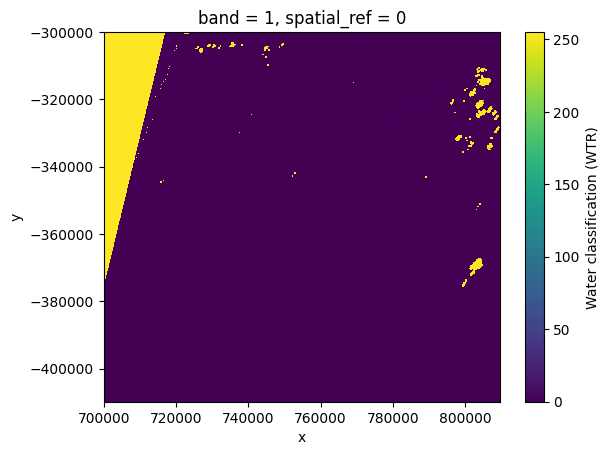

In [133]:
array.squeeze().plot()

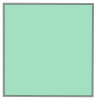

In [141]:
AOI

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from rasterio.warp import transform_bounds

transformed_bounds = transform_bounds("EPSG:4326", array.rio.crs, *AOI.bounds)

In [148]:
transformed_bounds

(749836.4899417162, -361368.7268228959, 807307.339063789, -302143.89889018843)

In [151]:
array.rio.clip_box?

Signature:
array.rio.clip_box(
    minx: float,
    miny: float,
    maxx: float,
    maxy: float,
    *,
    auto_expand: Union[bool, int] = False,
    auto_expand_limit: int = 3,
    crs: Optional[Any] = None,
    allow_one_dimensional_raster: bool = False,
) -> xarray.core.dataarray.DataArray
Docstring:
Clip the :obj:`xarray.DataArray` by a bounding box.

.. versionadded:: 0.12 crs
.. versionadded:: 0.16 allow_one_dimensional_raster

Parameters
----------
minx: float
    Minimum bound for x coordinate.
miny: float
    Minimum bound for y coordinate.
maxx: float
    Maximum bound for x coordinate.
maxy: float
    Maximum bound for y coordinate.
auto_expand: Union[bool, int]
    If True, it will expand clip search if only 1D raster found with clip.
auto_expand_limit: int
    maximum number of times the clip will be retried before raising
    an exception.
crs: :obj:`rasterio.crs.CRS`, optional
    The CRS of the bounding box. Default is to assume it is the same
    as the dataset.
all

In [152]:
array.rio.clip_box(*AOI.bounds, crs="epsg:4326")

<xarray.DataArray (band: 1, y: 1975, x: 1917)> Size: 4MB
array([[[0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0],
        ...,
        [0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0]]], dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 15kB 7.498e+05 7.499e+05 ... 8.073e+05 8.073e+05
  * y            (y) float64 16kB -3.021e+05 -3.022e+05 ... -3.614e+05
    spatial_ref  int64 8B 0
Attributes: (12/48)
    ACCODE:                                                                  ...
    AEROSOL_CLASS_REMAPPING_ENABLED:                                         ...
    AEROSOL_NOT_WATER_TO_HIGH_CONF_WATER_FMASK_VALUES:                       ...
    AEROSOL_PARTIAL_SURFACE_AGGRESSIVE_TO_HIGH_CONF_WATER_FMASK_VALUES:      ...
    AEROSOL_PARTIAL_SURFACE_WATER_CONSERVATIVE_TO_HIGH_CONF_WATER_FMASK_VALUE...
    AEROSOL_WATER_MODERATE_CONF_TO_HIGH_CONF_WATER_FMASK_VALUES:             ...
    ...                                                                          ...
    WORLDCOVER_SOURCE:                                                       ...
    AREA_OR_POINT:                                                           ...
    scale_factor:                                                            ...
    add_offset:                                                              ...
    long_name:                                                               ...
    _FillValue:                                                              ...

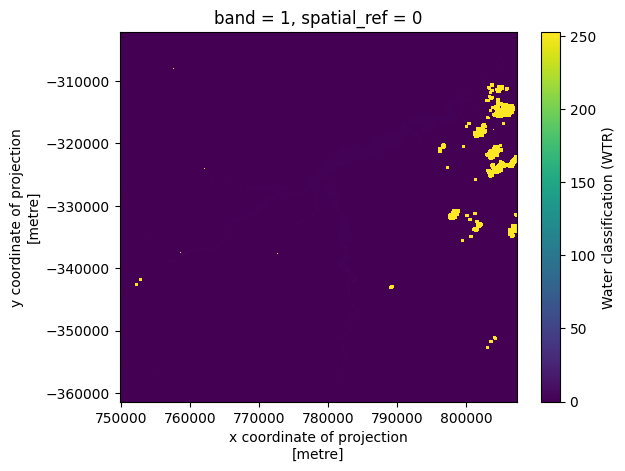

In [153]:
array.rio.clip_box(*AOI.bounds, crs="epsg:4326").squeeze().plot()

In [156]:
from pyproj import Transformer
import shapely

In [159]:
# from: https://shapely.readthedocs.io/en/latest/reference/shapely.transform.html
transformer = Transformer.from_crs("epsg:4326", array.rio.crs, always_xy=True)
aoi_transformed = shapely.transform(AOI, transformer.transform, interleaved=False)

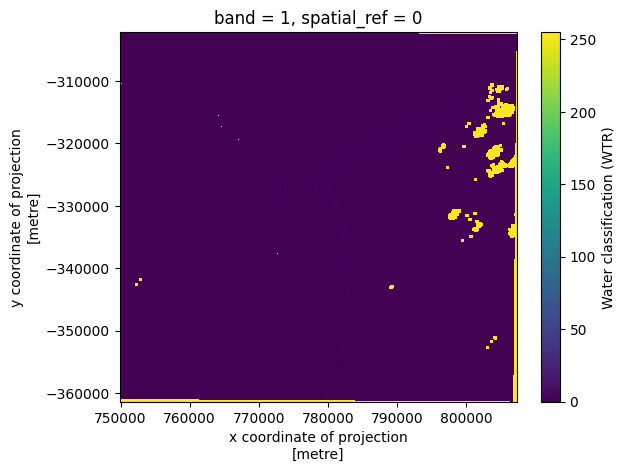

In [164]:
array.rio.clip([aoi_transformed], drop=True).squeeze().plot()

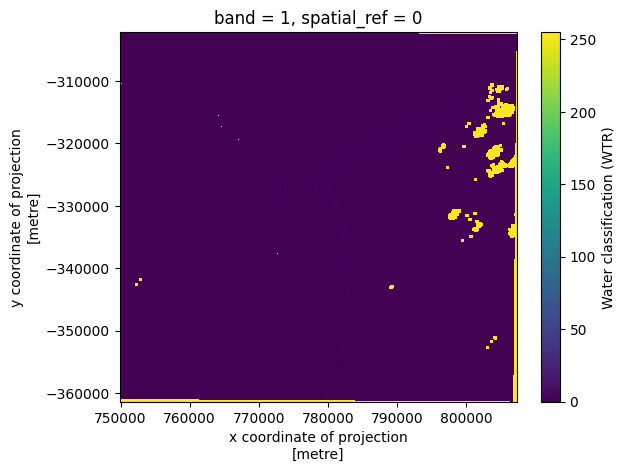

In [167]:
array.rio.clip([AOI], crs="epsg:4326", drop=True).squeeze().plot()

In [168]:
type(array)

xarray.core.dataarray.DataArray

In [74]:
file.details["name"]

'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_V1/OPERA_L3_DSWx-HLS_T21MYS_20240808T140051Z_20240810T064007Z_S2A_30_v1.0_B01_WTR.tif'

In [8]:
array = xrio.open_rasterio(url_files[0])
array

<xarray.DataArray (band: 1, y: 3660, x: 3660)> Size: 13MB
[13395600 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB 7e+05 7e+05 7e+05 ... 8.097e+05 8.097e+05
  * y            (y) float64 29kB -3e+05 -3e+05 ... -4.098e+05 -4.098e+05
    spatial_ref  int64 8B 0
Attributes: (12/48)
    ACCODE:                                                                  ...
    AEROSOL_CLASS_REMAPPING_ENABLED:                                         ...
    AEROSOL_NOT_WATER_TO_HIGH_CONF_WATER_FMASK_VALUES:                       ...
    AEROSOL_PARTIAL_SURFACE_AGGRESSIVE_TO_HIGH_CONF_WATER_FMASK_VALUES:      ...
    AEROSOL_PARTIAL_SURFACE_WATER_CONSERVATIVE_TO_HIGH_CONF_WATER_FMASK_VALUE...
    AEROSOL_WATER_MODERATE_CONF_TO_HIGH_CONF_WATER_FMASK_VALUES:             ...
    ...                                                                          ...
    WORLDCOVER_SOURCE:                                                       ...
    AREA_OR_POINT:                                                           ...
    _FillValue:                                                              ...
    scale_factor:                                                            ...
    add_offset:                                                              ...
    long_name:                                                               ...

In [11]:
# Visualize B01 - WATER CLASSIFICATION LAYER
# Parameters for Colorbar
levels = [0, 0.9, 1.9, 2.9, 7.9, 8.9, 10]
color_key = {
    "Not Water": "#ffffff",
    "Open Water": "#0000ff",
    "Partial Surface Water": "#00ff00",
    "Reserved": "#000000",
    "Snow/Ice": "#00ffff",
    "Clouds/Cloud Shadow": "#7f7f7f",
}

ticks = [0.5, 1.5, 2.5, 5.5, 8.5, 9.5]
ticker = FixedTicker(ticks=ticks)
labels = dict(zip(ticks, color_key, strict=False))


array.hvplot.image(
    x="x",
    y="y",
    color_levels=levels,
    frame_width=800,
    frame_height=800,
).opts(
    title=f"B01 WTR",
    xlabel="Longitude",
    ylabel="Latitude",
    color_levels=levels,
    cmap=tuple(color_key.values()),
    colorbar_opts={"ticker": ticker, "major_label_overrides": labels},
    clim=(0, 10),
)


BokehModel(combine_events=True, render_bundle={'docs_json': {'01aaec4b-7f8a-46d8-89b8-05e56327b0a2': {'version…

In [85]:
proj_aoi_bounds = rio.warp.transform_bounds("epsg:4326", ds.crs, *AOI.bounds)

In [86]:
window = rio.windows.from_bounds(*proj_aoi_bounds, transform=ds.transform)

In [95]:
array = ds.read(window=window)

In [88]:
array.shape

(1, 255, 1916)

In [97]:
array = ds.read()

In [98]:
window

Window(col_off=1662.5496647238724, row_off=3405.4632963396143, width=1915.6949707357599, height=1974.1609310902477)

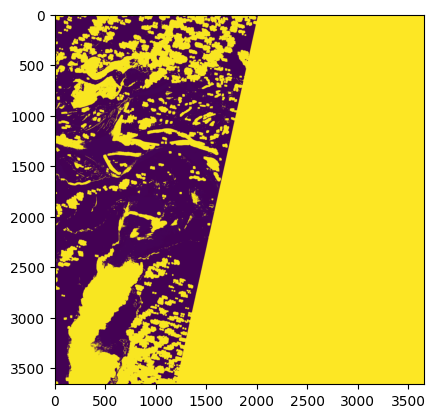

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(array.squeeze())

In [160]:
ds.colormap(1)

{0: (255, 255, 255, 255),
 1: (0, 0, 255, 255),
 2: (180, 213, 244, 255),
 3: (0, 0, 0, 255),
 4: (0, 0, 0, 255),
 5: (0, 0, 0, 255),
 6: (0, 0, 0, 255),
 7: (0, 0, 0, 255),
 8: (0, 0, 0, 255),
 9: (0, 0, 0, 255),
 10: (0, 0, 0, 255),
 11: (0, 0, 0, 255),
 12: (0, 0, 0, 255),
 13: (0, 0, 0, 255),
 14: (0, 0, 0, 255),
 15: (0, 0, 0, 255),
 16: (0, 0, 0, 255),
 17: (0, 0, 0, 255),
 18: (0, 0, 0, 255),
 19: (0, 0, 0, 255),
 20: (0, 0, 0, 255),
 21: (0, 0, 0, 255),
 22: (0, 0, 0, 255),
 23: (0, 0, 0, 255),
 24: (0, 0, 0, 255),
 25: (0, 0, 0, 255),
 26: (0, 0, 0, 255),
 27: (0, 0, 0, 255),
 28: (0, 0, 0, 255),
 29: (0, 0, 0, 255),
 30: (0, 0, 0, 255),
 31: (0, 0, 0, 255),
 32: (0, 0, 0, 255),
 33: (0, 0, 0, 255),
 34: (0, 0, 0, 255),
 35: (0, 0, 0, 255),
 36: (0, 0, 0, 255),
 37: (0, 0, 0, 255),
 38: (0, 0, 0, 255),
 39: (0, 0, 0, 255),
 40: (0, 0, 0, 255),
 41: (0, 0, 0, 255),
 42: (0, 0, 0, 255),
 43: (0, 0, 0, 255),
 44: (0, 0, 0, 255),
 45: (0, 0, 0, 255),
 46: (0, 0, 0, 255),
 47: (0, 